In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Palette ───────────────────────────────────────────────────
MODELS_3   = ['MLP', 'CNN', 'LSTM']
MODELS_4   = ['MLP', 'CNN', 'LSTM', 'Transformer']
COLORS_3   = ['#4C72B0', '#DD8452', '#55A868']
COLORS_4   = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

# ════════════════════════════════════════════════════════════════
# FIG 1 — Training curves (all 4 models, val only for clarity)
# ════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
fig.suptitle('Training Curves — All Models', fontsize=13, fontweight='bold')

for hist, label, color in zip(
    [mlp_history, cnn_history, lstm_history, transformer_history],
    MODELS_4, COLORS_4
):
    epochs = range(1, len(hist['train_loss']) + 1)
    axes[0].plot(epochs, hist['train_loss'], color=color, linestyle='--', alpha=0.4)
    axes[0].plot(epochs, hist['val_loss'],   color=color, label=label)
    axes[1].plot(epochs, hist['train_f1'],   color=color, linestyle='--', alpha=0.4)
    axes[1].plot(epochs, hist['val_f1'],     color=color, label=label)
    axes[2].plot(epochs, hist['val_acc'],    color=color, label=label)

titles = ['Loss', 'Macro F1', 'Val Accuracy']
ylabels = ['Loss', 'Macro F1', 'Accuracy']
for ax, t, y in zip(axes, titles, ylabels):
    ax.set_title(f'Val {t} (solid) / Train {t} (dashed)', fontsize=10)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(y)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig1_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# ════════════════════════════════════════════════════════════════
# FIG 2 — Summary bar: Val F1 / Test Acc / Test macro-F1 (4 models)
# ════════════════════════════════════════════════════════════════
# Fill in your actual numbers below
val_f1_4    = [0.416, 0.484, 0.506, 0.402]
test_acc_4  = [0.641, 0.756, 0.723, 0.559]
test_mf1_4  = [0.477, 0.547, 0.542, 0.459]

x = np.arange(len(MODELS_4))
w = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w, val_f1_4,   w, label='Best Val F1',      color='#4C72B0', alpha=0.85)
ax.bar(x,     test_acc_4, w, label='Test Accuracy',    color='#DD8452', alpha=0.85)
ax.bar(x + w, test_mf1_4, w, label='Test Macro F1',    color='#55A868', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(MODELS_4, fontsize=12)
ax.set_ylim(0, 1.0)
ax.set_ylabel('Score')
ax.set_title('Frame-Level Classification Summary — All Models', fontsize=12, fontweight='bold')
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
for bars in ax.containers:
    ax.bar_label(bars, fmt='%.3f', fontsize=8, padding=2)
plt.tight_layout()
plt.savefig('fig2_summary_bars.png', dpi=150, bbox_inches='tight')
plt.show()

# ════════════════════════════════════════════════════════════════
# FIG 3 — mAP threshold sweep  (MLP / CNN / LSTM only)
# ════════════════════════════════════════════════════════════════
thresholds = [0.2, 0.3, 0.4, 0.5]
mlp_maps   = [0.057, 0.058, 0.060, 0.060]
cnn_maps   = [0.084, 0.087, 0.088, 0.089]
lstm_maps  = [0.078, 0.084, 0.083, 0.088]

fig, ax = plt.subplots(figsize=(7, 4.5))
for vals, label, color in zip(
    [mlp_maps, cnn_maps, lstm_maps], MODELS_3, COLORS_3
):
    ax.plot(thresholds, vals, marker='o', label=label, color=color, linewidth=2)
ax.set_xlabel('Confidence Threshold')
ax.set_ylabel('mAP@0.5')
ax.set_title('mAP@0.5 vs. Confidence Threshold', fontsize=12, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig3_map_threshold_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

# ════════════════════════════════════════════════════════════════
# FIG 4 — mAP IoU sweep  (MLP / CNN / LSTM only)
# ════════════════════════════════════════════════════════════════
iou_thresholds = [0.3, 0.4, 0.5]
mlp_iou  = [0.147, 0.100, 0.058]
cnn_iou  = [0.180, 0.131, 0.087]

lstm_iou = [0.174, 0.126, 0.082]    # fix this

fig, ax = plt.subplots(figsize=(7, 4.5))
for vals, label, color in zip(
    [mlp_iou, cnn_iou, lstm_iou], MODELS_3, COLORS_3
):
    ax.plot(iou_thresholds, vals, marker='s', label=label, color=color, linewidth=2)
ax.set_xlabel('IoU Threshold')
ax.set_ylabel('mAP')
ax.set_title('mAP vs. IoU Threshold (conf th=0.3)', fontsize=12, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig4_map_iou_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

# ════════════════════════════════════════════════════════════════
# FIG 5 — Per-class AP heatmap  (MLP / CNN / LSTM)
# ════════════════════════════════════════════════════════════════
classes = [
    'BaseballPitch','ThrowDiscus','CricketShot','JavelinThrow',
    'GolfSwing','BasketballDunk','Diving','HammerThrow','LongJump',
    'CricketBowling','Billiards','Shotput','VolleyballSpiking',
    'PoleVault','CliffDiving','HighJump','CleanAndJerk',
    'FrisbeeCatch','SoccerPenalty','TennisSwing'
]
mlp_ap  = [0.048, 0.025, 0.051, 0.049, 0.085, 0.105, 0.012, 0.074, 0.091, 0.081, 0.021,
           0.039, 0.046, 0.064, 0.154, 0.026, 0.116, 0.015, 0.020, 0.027]

cnn_ap  = [0.104, 0.146, 0.059, 0.053, 0.089, 0.112, 0.042, 0.098, 0.103, 0.096,
           0.049, 0.155, 0.093, 0.114, 0.154, 0.092, 0.078, 0.024, 0.050, 0.019]

lstm_ap = [0.080,0.099,0.041,0.064,0.159,0.099,0.035,0.119,0.124,
           0.075,0.015,0.111,0.073,0.106,0.179,0.098,0.084,0.010,0.020,0.042]    # fix this

data_ap = np.array([mlp_ap, cnn_ap, lstm_ap])

fig, ax = plt.subplots(figsize=(15, 3))
im = ax.imshow(data_ap, aspect='auto', cmap='YlOrRd', vmin=0, vmax=0.20)
ax.set_xticks(range(len(classes)))
ax.set_xticklabels(classes, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(3)); ax.set_yticklabels(MODELS_3, fontsize=10)
for i in range(3):
    for j in range(len(classes)):
        ax.text(j, i, f'{data_ap[i,j]:.2f}', ha='center', va='center', fontsize=7)
plt.colorbar(im, ax=ax, fraction=0.015, pad=0.02, label='AP@0.5')
ax.set_title('Per-Class AP @ IoU=0.5 (conf th=0.3)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig5_perclass_ap_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# ════════════════════════════════════════════════════════════════
# FIG 6 — Per-class F1 heatmap  (all 4 models)
# ════════════════════════════════════════════════════════════════
mlp_f1  = [0.321, 0.397, 0.313, 0.305, 0.424, 0.637, 0.548, 0.480, 0.457, 0.411, 0.355, 0.434, 0.412, 0.699, 0.638, 0.453, 0.723, 0.363, 0.450, 0.472]

cnn_f1  = [0.484,0.518,0.397,0.345,0.431,0.717,0.697,0.545,0.504,
           0.508,0.424,0.463,0.429,0.726,0.766,0.489,0.687,0.406,0.561,0.566]
lstm_f1 = [0.464, 0.472, 0.402, 0.369, 0.380, 0.682, 0.657, 0.543, 0.526, 0.500, 0.410, 0.539, 0.386, 0.730, 0.736, 0.570, 0.745, 0.405, 0.479, 0.578]

tr_f1   = [0.337, 0.416, 0.287, 0.287, 0.352, 0.568, 0.546, 0.504, 0.455, 0.334, 0.337, 0.463, 0.429, 0.695, 0.632, 0.482, 0.694, 0.357, 0.414, 0.437]

data_f1 = np.array([mlp_f1, cnn_f1, lstm_f1, tr_f1])

fig, ax = plt.subplots(figsize=(15, 4))
im = ax.imshow(data_f1, aspect='auto', cmap='Blues', vmin=0.20, vmax=0.80)
ax.set_xticks(range(len(classes)))
ax.set_xticklabels(classes, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(4)); ax.set_yticklabels(MODELS_4, fontsize=10)
for i in range(4):
    for j in range(len(classes)):
        ax.text(j, i, f'{data_f1[i,j]:.2f}', ha='center', va='center', fontsize=7)
plt.colorbar(im, ax=ax, fraction=0.012, pad=0.02, label='F1')
ax.set_title('Per-Class Test F1-Score — All Models (Transformer: frame-level only)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('fig6_perclass_f1_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# ════════════════════════════════════════════════════════════════
# FIG 7 — mAP@0.5 bar (best threshold, MLP/CNN/LSTM only)
# ════════════════════════════════════════════════════════════════
best_maps = [0.055, 0.089, 0.088]  # at best threshold per model

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(MODELS_3, best_maps, color=COLORS_3, alpha=0.85, edgecolor='black', linewidth=0.6)
ax.bar_label(bars, fmt='%.3f', fontsize=11, padding=3)
ax.set_ylim(0, 0.15)
ax.set_ylabel('mAP@0.5')
ax.set_title('Temporal Detection mAP@0.5\n(Best Confidence Threshold)', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig7_map_bar.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ All 7 figures saved.")

In [ ]:
!git clone https://github.com/open-mmlab/mmaction2.git

import torch
import numpy as np
import json
import matplotlib.pyplot as plt
import os
import glob
from pathlib import Path
import pandas as pd
from torchsummary import summary
import torch.nn.functional as F

device = 'cuda' if torch.cuda.is_available() else 'cpu'

Cloning into 'mmaction2'...
remote: Enumerating objects: 22868, done.
remote: Counting objects: 100% (2/2), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 22868 (delta 0), reused 0 (delta 0), pack-reused 22866 (from 2)
Receiving objects: 100% (22868/22868), 69.62 MiB | 19.46 MiB/s, done.
Resolving deltas: 100% (16120/16120), done.


In [ ]:
! ls mmaction2/tools/data/thumos14/

denormalize_proposal_file.sh  extract_rgb_frames.sh
download_annotations.sh       fetch_tag_proposals.sh
download_videos.sh	      README.md
extract_frames.sh	      README_zh-CN.md
extract_rgb_frames_opencv.sh


In [ ]:
%cd /content/mmaction2/tools/data/thumos14

!bash download_annotations.sh

%cd /content

/content/mmaction2/tools/data/thumos14
../../../data/thumos14/ does not exist. Creating
--2026-05-09 20:22:57--  http://crcv.ucf.edu/THUMOS14/Validation_set/TH14_Temporal_annotations_validation.zip
Resolving crcv.ucf.edu (crcv.ucf.edu)... 132.170.214.127
Connecting to crcv.ucf.edu (crcv.ucf.edu)|132.170.214.127|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://www.crcv.ucf.edu/THUMOS14/Validation_set/TH14_Temporal_annotations_validation.zip [following]
--2026-05-09 20:22:57--  https://www.crcv.ucf.edu/THUMOS14/Validation_set/TH14_Temporal_annotations_validation.zip
Resolving www.crcv.ucf.edu (www.crcv.ucf.edu)... 132.170.214.127
Connecting to www.crcv.ucf.edu (www.crcv.ucf.edu)|132.170.214.127|:443... connected.
  Unable to locally verify the issuer's authority.
HTTP request sent, awaiting response... 200 OK
Length: 209558 (205K) [application/zip]
Saving to: ‘TH14_Temporal_annotations_validation.zip’

TH14_Temporal_annot 100%[============

In [ ]:
! cp -r /content/mmaction2/data /content/

In [ ]:
! cat data/thumos14/annotations_test/readme.txt

THUMOS CHALLENGE 2014
http://crcv.ucf.edu/THUMOS14/

------------------------------------------------------------

This folder contains the temporal annotations of action instances in 
the test vides of 20 classes (list provided below).

The folder 'annotations' contains text files each including the 
temporal locations of instances of one class. Each row denotes 
one instance with the following format:

[video_name starting_time ending_time]

The starting_time and ending_time are in seconds (1 decimal 
point precision).

Note that one video may include actions of multiple classes 
and multiple instances of one action. The meta 
file (http://crcv.ucf.edu/THUMOS14/Test_set/test_set_meta.zip) 
specifies  what class(es) are observed in each video.

The file 'Ambiguous_val.txt' includes the temporal parts of the 
video which were hard to be labeled as action or no-action (e.g., the 
moments immediately before the actions starts). Such segments are 
taken out of the evaluations.

The file T

In [ ]:
!ls data/thumos14/annotations_test/

Ambiguous_test.txt	 HighJump_test.txt
BaseballPitch_test.txt	 JavelinThrow_test.txt
BasketballDunk_test.txt  LongJump_test.txt
Billiards_test.txt	 PoleVault_test.txt
CleanAndJerk_test.txt	 readme.txt
CliffDiving_test.txt	 Shotput_test.txt
CricketBowling_test.txt  SoccerPenalty_test.txt
CricketShot_test.txt	 TennisSwing_test.txt
Diving_test.txt		 TH14_Temporal_annotations_Test_ViperXGTF.zip
FrisbeeCatch_test.txt	 ThrowDiscus_test.txt
GolfSwing_test.txt	 VolleyballSpiking_test.txt
HammerThrow_test.txt


In [ ]:
!cat /content/data/thumos14/annotations_val/SoccerPenalty_val.txt

video_validation_0000851  11.8 15.7
video_validation_0000851  17.4 20.5
video_validation_0000852  3.2 6.5
video_validation_0000852  12.8 15.8
video_validation_0000852  16.6 20.4
video_validation_0000852  21.4 24.5
video_validation_0000852  25.8 28.8
video_validation_0000852  34.8 37.5
video_validation_0000852  38.1 41.8
video_validation_0000852  43.9 46.5
video_validation_0000852  47.2 50.0
video_validation_0000852  57.6 60.7
video_validation_0000852  61.1 64.0
video_validation_0000852  70.8 73.7
video_validation_0000852  80.2 82.6
video_validation_0000852  84.2 86.6
video_validation_0000852  90.0 94.4
video_validation_0000852  101.7 104.6
video_validation_0000852  105.0 107.9
video_validation_0000852  114.4 117.2
video_validation_0000852  124.0 126.5
video_validation_0000852  127.5 131.0
video_validation_0000852  134.7 138.4
video_validation_0000852  145.3 148.2
video_validation_0000852  149.6 151.7
video_validation_0000852  152.7 155.1
video_validation_0000852  157.8 161.0
video_vali

In [ ]:
import os
import glob
from pathlib import Path
import pandas as pd

rows = {'video_name': [],
        'label': [],
        'start': [],
        'end': [],
        'split': []}

base_path = Path('/content/data/thumos14/')

for split in ['val', 'test']:
  new_path = base_path / f'annotations_{split}'
  for file in os.listdir(new_path):
    if not file.startswith(('Ambiguous', 'readme')) and file.endswith('.txt'):
      file_path = new_path / file
      label, splt = file_path.stem.split('_')
      with open(file_path, 'r') as f:
        for line in f:
          name, start, end = line.strip().split()
          rows['video_name'].append(name)
          rows['label'].append(label)
          rows['start'].append(float(start))
          rows['end'].append(float(end))
          rows['split'].append(split)

df = pd.DataFrame(rows)
df.head()


,video_name,label,start,end,split
0,video_validation_0000266,BaseballPitch,72.8,76.4,val
1,video_validation_0000681,BaseballPitch,44.0,50.9,val
2,video_validation_0000682,BaseballPitch,1.5,5.4,val
3,video_validation_0000682,BaseballPitch,79.3,83.9,val
4,video_validation_0000683,BaseballPitch,0.3,5.5,val


In [ ]:
df_val = df[df['split'] == 'val'].copy()
df_test = df[df['split'] == 'test'].copy()

print(f'Unique classes in the dataset: {df.label.nunique()}\n')

print(f'Label count for Vaidation set: \n{df_val.label.value_counts()}\n')
# print(f'Label count for Test set: \n{df_test.label.value_counts()}\n')

Unique classes in the dataset: 20

Label count for Vaidation set: 
label
Diving               499
BasketballDunk       303
HighJump             271
HammerThrow          199
JavelinThrow         192
CricketShot          181
CricketBowling       178
LongJump             163
VolleyballSpiking    146
CliffDiving          143
PoleVault            120
ThrowDiscus          120
FrisbeeCatch         103
Billiards             81
Shotput               70
TennisSwing           69
SoccerPenalty         66
CleanAndJerk          42
GolfSwing             31
BaseballPitch         30
Name: count, dtype: int64



In [ ]:
print(f'Mean action duration overall: {(df['end'] - df['start']).mean().item()}')

Mean action duration overall: 4.273385703063629


<Axes: xlabel='Mean Duration (seconds)', ylabel='Action Name'>

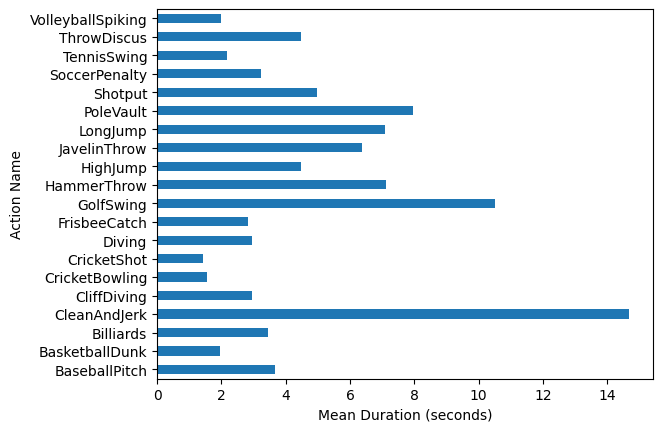

In [ ]:
means = df_val.groupby('label')[['end', 'start']].apply(lambda x: (x['end'] - x['start']).mean())
means.plot(kind='barh', xlabel="Mean Duration (seconds)", ylabel="Action Name")

<Axes: xlabel='Mean Duration (seconds)', ylabel='Action Name'>

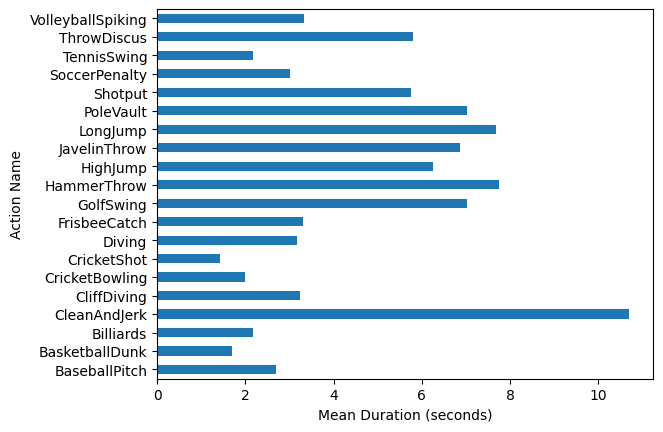

In [ ]:
means = df_test.groupby('label')[['end', 'start']].apply(lambda x: (x['end'] - x['start']).mean())
means.plot(kind='barh', xlabel="Mean Duration (seconds)", ylabel="Action Name")

In [ ]:
print(f"Unique videos overall: {df['video_name'].nunique()}")
print(f"Unique videos in Validation set: {df_val['video_name'].nunique()}")
print(f"Unique videos in Testing set: {df_test['video_name'].nunique()}")

Unique videos overall: 412
Unique videos in Validation set: 200
Unique videos in Testing set: 212


Now we need to download I3D features as our videos:

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import os

DRIVE_DIR = '/content/drive/MyDrive/thumos_i3d'

# Walk the entire directory and show everything
for root, dirs, files in os.walk(DRIVE_DIR):
    level = root.replace(DRIVE_DIR, '').count(os.sep)
    indent = '  ' * level
    print(f"{indent}{os.path.basename(root)}/")
    if files:
        subindent = '  ' * (level + 1)
        for f in files[:5]:  # show first 5 files per folder
            print(f"{subindent}{f}")
        if len(files) > 5:
            print(f"{subindent}... and {len(files)-5} more")

thumos_i3d/
  thumos_i3d/
    i3d_actionformer_stride4_thumos/
      i3d_actionformer_stride4_thumos/
        video_validation_0000289.npy
        video_test_0000991.npy
        video_validation_0000790.npy
        video_test_0000737.npy
        video_validation_0000989.npy
        ... and 409 more


In [ ]:
import shutil, os

SRC = '/content/drive/MyDrive/thumos_i3d/thumos_i3d/i3d_actionformer_stride4_thumos/i3d_actionformer_stride4_thumos'
DST = '/content/i3d_features'

os.makedirs(DST, exist_ok=True)
shutil.copytree(SRC, DST, dirs_exist_ok=True)
print("Copy done.")

Copy done.


In [ ]:
import glob

i3d_videos = {}
failed = []
FEATURE_DIR = '/content/i3d_features'

for path in glob.glob(f'{FEATURE_DIR}/*.npy'):
    video_name = os.path.basename(path).replace('.npy', '')
    try:
        i3d_videos[video_name] = np.load(path)
    except Exception as e:
        failed.append((video_name, str(e)))

print(f"Loaded: {len(i3d_videos)} videos")
print(f"Failed: {len(failed)} files")
if failed:
    for name, err in failed[:5]:
        print(f"  {name}: {err}")

Loaded: 413 videos
Failed: 0 files


I3D features are essentially array representation of a video.

When we were doing images with CNN, we were using 2D convolutions
on a 2D images. With videos, the problem is different - we need to get sense of a time as well. I3D processes **chunks** of frames at once - this allows it to get sense of the time dependencies on top of appearances.

Standard 2D CNN:
* Image: `H x W` (with colors `H x W x C`)

I3D features:
* Chunk of images: `T x H x W` (with colors `T × H × W × C`)

So we essentially convolve with **4D rectangle** over videos.

In our case it works somewhat like that:
1. Split the video into `n` chunks of `x` frames
2. Run them through specific model (some kind of CNN)
3. Stop at the second to last layer (where features are in vector), right
before the classification layer.
4. Output `vectors` instead of labels - the resulting shape would look like
`[num_chunks x 2048]`

This way we get abstract representation of videos (it is already "prepared", so it knows where is leg motion, kick, etc.). We get information about what's happening in videos without final labels in a much smaller size (2D arrays).

The original THUMOS-14 videos were recorded at 30 fps, and the i3d features I downloaded were named `i3d_actionformer_stride4_thumos`.

It means they feature vectors were extracted every `4` frames.

Thus, `1 second = 30 frames = 30 / 4 = 7.5 timestamps`

So the formula for timestep is:
$$
timestep = seconds * 7.5
$$

In [ ]:
import random
def seconds_to_timestep(start, finish, fps=30, stride=4):
  start_time = start * (fps / stride)
  end_time = finish * (fps / stride)
  return start_time, end_time

def vis_random_img_array(annotations, videos):
  vid_num = random.choice(list(i3d_videos.keys()))
  vid_array = videos[vid_num]
  fig, axes = plt.subplots(figsize=(20, 5))
  axes.imshow(vid_array.T, aspect='auto', cmap='viridis',
              vmin = np.percentile(vid_array, 5),
              vmax = np.percentile(vid_array, 95))

  labels = set()
  for idx, row in annotations[annotations['video_name'] == vid_num].iterrows():
    start, end = seconds_to_timestep(row['start'], row['end'])

    lbl = row['label'] if row['label'] not in labels else '_nolegend_'
    labels.add(row['label'])

    axes.axvline(start, color='red', linewidth=1.5,
                label=row['label'])
    axes.axvline(end, color='lime', linewidth=1.5)

  print(f"Actions in this vid: {list(labels)}")
  axes.set_xlabel("Timestep")
  axes.set_ylabel("Feature Dim")
  axes.set_title(f"Video: {vid_num}")
  plt.tight_layout()

In [ ]:
vis_random_img_array(df, i3d_videos)

Now let's try to visualize our arrays with `Embeddings':

In [ ]:
rand_vid = random.choice(list(i3d_videos.keys()))
features = i3d_videos[rand_vid]
print(f"Shape of one video: {features.shape}")

vid_df = df[df['video_name'] == rand_vid]
starts, ends = seconds_to_timestep(vid_df['start'], vid_df['end'])
starts = starts.round().astype(int)
ends = ends.round().astype(int)

# separate actions from backgrounds
action_mask = np.zeros(len(features), dtype=bool)
for s, e in zip(starts, ends):
    action_mask[s:e] = True

print(f"Action timesteps: {action_mask.sum()}, Background: {(~action_mask).sum()}")

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(features)

print(f"Variance explained by 2 dim: {pca.explained_variance_ratio_.sum():.2%}")

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(*embeddings_2d[action_mask].T, c='#0066CC', s=150, alpha=0.7, label='Action', edgecolors='black', linewidth=0.5)
ax.scatter(*embeddings_2d[~action_mask].T, c='#CC0099', s=150, alpha=0.7, label='Background', edgecolors='black', linewidth=0.5)

ax.set_xlabel('First Principal Component', fontsize=14)
ax.set_ylabel('Second Principal Component', fontsize=14)
ax.set_title(f'PCA of I3D features', fontsize=13)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()


For a random video, we can see that `Action` and `Background` are slightly separated. There is


In [ ]:
all_labels = []
all_features = []

for name, features in i3d_videos.items():
  vid_df = df[df['video_name'] == name]
  labels = np.array(['background'] * len(features), dtype=object)

  if len(vid_df) > 0:
    starts, ends = seconds_to_timestep(vid_df['start'], vid_df['end'])
    starts, ends = starts.round().astype(int), ends.round().astype(int)
    for (idx, row), s, e in zip(vid_df.iterrows(), starts, ends):

      labels[s:e] = row['label']

  all_features.append(features)
  all_labels.append(labels)

all_features = np.concatenate(all_features, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

print(f"Total timesteps: {len(all_features)}")
print(f"Background: {(all_labels == 'background').sum()}")
print(f"Action: {(all_labels != 'background').sum()}")

In [ ]:
N = 10000
idx = np.random.choice(len(all_features), size=N, replace=False)
sample_features = all_features[idx]
sample_labels = all_labels[idx]

pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(sample_features)
print(f"Variance explained: {pca.explained_variance_ratio_.sum():.2%}")

In [ ]:
mask = sample_labels != 'background'
fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(*embeddings_2d[~mask].T, c='#CC0099', s=10, alpha=0.3, label='Background')
ax.scatter(*embeddings_2d[mask].T,  c='#0066CC', s=10, alpha=0.3, label='Action')
ax.legend()
ax.set_title('PCA for all videos, action vs background')
plt.tight_layout()

In [ ]:
import matplotlib.cm as cm

unique_labels = sorted(set(sample_labels))
# unique_labels.remove('background')
colors = cm.tab20(np.linspace(0, 1, len(unique_labels)))
label_to_color = dict(zip(unique_labels, colors))

fig, ax = plt.subplots(figsize=(12, 8))
for label in unique_labels:
    mask = sample_labels == label
    if label == 'background':
      alpha = 0.15
      size  = 8
    else:
      alpha = 0.6
      size = 20
    ax.scatter(*embeddings_2d[mask].T,
               c=[label_to_color[label]], s=size, alpha=alpha, label=label)

ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ax.set_title('PCA — all videos, per-class')
plt.tight_layout(); plt.show()


In [ ]:
FPS = 30
STRIDE = 4
TIMESTEPS_PER_SEC = FPS / STRIDE
stride_sec = STRIDE / FPS

action_classes = df['label'].unique().tolist()

label2idx = {"background": 0}
for idx, label in enumerate(action_classes):
  label2idx[label] = idx + 1

idx2label = {v: k for k, v in label2idx.items()}
total_classes = len(label2idx)

print(f"Total classes: {total_classes} | 0=background, 1-20=actions")

Total classes: 21 | 0=background, 1-20=actions


In [ ]:
# now need to write a function to build a video labels for each video
# we are given the video and its timestamps, and our goal is to convert seconds in
# initial df to timeframes in the i3d features and output the array with the len of timeframes

def build_video_labels(video_name, features, annotations):
  vid_anns = annotations[annotations['video_name'] == video_name]
  T = features.shape[0]
  labels = np.zeros(T, dtype=np.int32)    # all background by default

  for _, row in vid_anns.iterrows():
    start = max(0, int(row['start'] * TIMESTEPS_PER_SEC))
    finish = min(T, int(row['end'] * TIMESTEPS_PER_SEC))
    class_id = label2idx.get(row['label'], 0)
    labels[start:finish] = class_id
  return labels


test_video_features  = {}
test_video_labels    = {}
train_video_features = {}
train_video_labels   = {}

for video_name, features in i3d_videos.items():
  labels = build_video_labels(video_name, features, df)
  if 'validation' in video_name:
    train_video_features[video_name] = features
    train_video_labels[video_name] = labels
  else:
    test_video_features[video_name] = features
    test_video_labels[video_name] = labels



In [ ]:
import random

all_train_vids = list(train_video_features.keys())
random.seed(42)
random.shuffle(all_train_vids)

split = int(0.8 * len(all_train_vids))
train_vids = all_train_vids[:split]
val_vids   = all_train_vids[split:]

train_feats_split  = {v: train_video_features[v] for v in train_vids}
train_labels_split = {v: train_video_labels[v] for v in train_vids}

val_feats_split  = {v: train_video_features[v] for v in val_vids}
val_labels_split = {v: train_video_labels[v] for v in val_vids}

print(f"Train videos: {len(train_vids)}\n"
      f"Val videos: {len(val_vids)}\n"
      f"Test videsos : {len(test_video_features)}")

Train videos: 160
Val videos: 40
Test videsos : 213


# Modeling

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import classification_report
from tqdm import trange
import copy
from sklearn.metrics import f1_score

"""
Need functions:
      * train_one_epoch - update parameters, iterate over all batches, record loss and some score at each point
      * eval_one_epoch - iterate over all batches and record indicators on val set
      * train_model    - train for specific num of epochs, record all the losses/metrics, output model, mb early stopping
      * evaluate_model - give classification report or total model assessment on test set
"""


def train_one_epoch(model, dataloader, criterion, optimizer, device):
  model.train()
  total_loss, correct, total = 0.0, 0, 0
  all_preds, all_true = [], []

  for batch_x, batch_y in dataloader:
    batch_x, batch_y = batch_x.to(device), batch_y.to(device)

    optimizer.zero_grad()
    logits = model(batch_x)
    loss = criterion(logits, batch_y)
    loss.backward()
    optimizer.step()

    preds = logits.argmax(1)

    total_loss += loss.item() * len(batch_y)
    correct += (preds == batch_y).sum().item()
    total += len(batch_y)

    all_preds.extend(preds.cpu().numpy())
    all_true.extend(batch_y.cpu().numpy())

  final_loss = total_loss / total
  final_acc = correct / total
  macro_f1   = f1_score(all_true, all_preds, average='macro', zero_division=0)

  return final_loss, final_acc, macro_f1


def eval_one_epoch(model, dataloader, criterion, device):
  model.eval()

  total_loss, correct, total = 0.0, 0, 0
  all_preds, all_true = [], []

  with torch.no_grad():
    for batch_x, batch_y in dataloader:
      batch_x, batch_y = batch_x.to(device), batch_y.to(device)

      logits = model(batch_x)
      loss = criterion(logits, batch_y)

      preds = logits.argmax(1)

      total_loss += loss * len(batch_y)
      correct += (preds == batch_y).sum().item()
      total += len(batch_y)

      all_preds.extend(preds.cpu().numpy())
      all_true.extend(batch_y.cpu().numpy())

  final_loss = total_loss / total
  final_acc = correct / total
  macro_f1 = f1_score(all_true, all_preds, average='macro', zero_division=0)

  return final_loss, final_acc, macro_f1


def train_model(model, train_loader, val_loader, criterion, optimizer,
                scheduler=None, num_epochs=30, patience=5, device=device):
  best_val_f1 = 0.0
  best_model = None
  patience_count = 0

  history = {'train_loss': [],
             'train_acc': [],
             'train_f1': [],
             'val_loss': [],
             'val_acc': [],
             'val_f1': []}

  for epoch in trange(num_epochs):
    train_loss, train_acc, train_f1 = train_one_epoch(model, train_loader, criterion,
                                                      optimizer, device)
    val_loss,   val_acc,   val_f1   = eval_one_epoch(model, val_loader, criterion, device)

    if scheduler:
      scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['train_f1'].append(train_f1)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    print(f"\nEpoch {epoch+1}:\n"
          f"Train loss: {train_loss:.3f} | acc: {train_acc:.3f} | f1: {train_f1:.3f}\n"
          f"Val loss: {val_loss:.3f} | acc: {val_acc:.3f} | f1: {val_f1:.3f}")

    if val_f1 > best_val_f1:
      best_val_f1 = val_f1
      best_model = copy.deepcopy(model.state_dict())
      patience_count = 0
    else:
      patience_count += 1
      if patience_count > patience:
        print(f"Stopped early at epoch: {epoch}")
        break

  model.load_state_dict(best_model)
  print(f"Final validation f1: {best_val_f1}")

  return model, history


def evaluate_model(model, loader, idx2label, num_classes, device):
  model.eval()
  all_preds, all_true = [], []

  with torch.no_grad():
    for batch_x, batch_y in loader:
      batch_x, batch_y = batch_x.to(device), batch_y.to(device)

      logits = model(batch_x)
      preds = logits.argmax(1)

      all_preds.extend(preds.cpu().numpy())
      all_true.extend(batch_y.cpu().numpy())

  target_names = [idx2label[i] for i in range(num_classes)]

  print(classification_report(all_true, all_preds, labels=list(range(num_classes)),
                            target_names=target_names, digits=3))

  return all_true, all_preds



Our classes are highly unbalanced, with dominating background class. Ordinary CrossEntropyLoss is not very good here, as it treats **all examples equally** - meaning correctly predicted background would contribute the same as correctly predicted minority class.

That's why we need to modify it a little bit, so easy-to-classify examples contribute much less to the loss than hard-to-classify ones.

This is so called `Focal Loss`:

In [ ]:
class FocalLoss(nn.Module):
  def __init__(self, gamma=2.0, alpha=None, reduction='mean'):
    super().__init__()
    self.gamma = gamma
    if alpha is not None:
      self.register_buffer('alpha', alpha)
    else:
      self.alpha = None

    self.reduction = reduction

  def forward(self, logits, targets):
    # 1) Compute log-probs
    log_probs = F.log_softmax(logits, dim=1)       # [B, C]
    probs = torch.exp(log_probs)                   # [B, C]

    # 2) Gather p_t (prob of the true class for each example)
    #   and log p_t
    targets = targets.view(-1, 1)                      # [B, 1]
    log_p_t = log_probs.gather(1, targets).squeeze(1)  # [B]
    p_t = probs.gather(1, targets).squeeze(1)          # [B]

    # 3) compute the modulas factor (1 - p_t)^gamma
    focal_factor = (1.0 - p_t) ** self.gamma

    # 4) apply alpha if provided
    if self.alpha is not None:
      # alpha_t: weight for the true class of each example
      alpha_t = self.alpha[targets.squeeze(1)]     # [B]
      focal_factor = focal_factor * alpha_t

    # 5) Compute focal loss
    loss = -focal_factor * log_p_t

    if self.reduction == 'mean':
      return loss.mean()
    elif self.reduction == 'sum':
      return loss.sum()
    else:
      return loss


NUM_CLASSES = 21
# Build counts over numeric labels, not strings
all_train_labels = np.concatenate(list(train_labels_split.values()))  # from your label dicts
counts = np.bincount(all_train_labels, minlength=NUM_CLASSES).astype(np.float32)  # length 21

# Avoid division by zero: if some class never appears, set its count to 1
counts[counts == 0] = 1.0

freq = counts
inv_freq = 1.0 / freq
alpha_np = inv_freq / inv_freq.sum()          # optional normalization
alpha = torch.tensor(alpha_np, dtype=torch.float32)
print("alpha shape:", alpha.shape)            # should be torch.Size([21])

alpha shape: torch.Size([21])


We also need to find proposals from predicted timesteps:

In [ ]:
def find_segments(mask):
  """
  mask: 1D boolean array of shape [T]
  returns: list of (start_idx, end_idx) inclusive
  """
  mask = np.asarray(mask, dtype=bool)
  T = len(mask)

  segments = []
  in_segment = False
  start = 0

  for t in range(T):
    if mask[t] and not in_segment:
      # starting a new segment
      in_segment = True
      start = t

    elif not mask[t] and in_segment:
      # closing the current segment at t-1
      in_segment = False
      end = t - 1
      if end >= start:
        segments.append((start, end))

  # if segments ended while in a segment
  if in_segment:
    segments.append((start, T-1))

  return segments



def extract_proposals_for_video(
    probs,                      # numpy array [T, C]
    video_id,
    stride_sec,
    th=0.3,
    background_id=0
):
    """
    Convert per-frame class probabilities into temporal proposals.
    Returns: list of dicts with keys: video_id, label_id, start, end, score
    """
    T, C = probs.shape
    proposals = []

    for c in range(C):
        if c == background_id:
            continue  # skip background

        p_c = probs[:, c]         # [T]
        mask = p_c >= th          # boolean [T]

        min_len = int(0.5 / stride_sec)
        segments = find_segments(mask)
        for (start_idx, end_idx) in segments:
            # Segment duration
            if end_idx <= start_idx:
                continue
            if (end_idx - start_idx + 1) < min_len:
                continue

            # Convert indices to seconds
            start_time = start_idx * stride_sec
            end_time   = (end_idx + 1) * stride_sec

            # Score: mean prob over the segment
            score = float(p_c[start_idx:end_idx+1].mean())

            proposals.append({
                "video_id": video_id,
                "label_id": c,
                "start": start_time,
                "end": end_time,
                "score": score,
            })

    return proposals


def generate_proposals_for_dataset(
    model,
    video_features_dict,
    stride_sec,
    device,
    th=0.3,
    background_id=0,
):
    model.eval()
    all_proposals = []

    with torch.no_grad():
        for video_name, feats in video_features_dict.items():
            # feats: [T, D]
            feats_t = torch.tensor(feats, dtype=torch.float32, device=device).unsqueeze(0)  # [1, T, D]

            logits = model(feats_t)   # expect [1, T, C] from your CNN
            if logits.dim() == 3:
                logits = logits[0]    # [T, C]

            probs = torch.softmax(logits, dim=-1).cpu().numpy()  # [T, C]

            proposals = extract_proposals_for_video(
                probs,
                video_id=video_name,
                stride_sec=stride_sec,
                th=th,
                background_id=background_id,
            )
            all_proposals.extend(proposals)

    return all_proposals

In [ ]:
from collections import defaultdict

def build_gt_dict(df, label2idx):
    """
    df: your annotations dataframe with columns [video_name, start, end, label]
    Returns: {video_id: [{'label_id': int, 'start': float, 'end': float}, ...]}
    """
    gt = defaultdict(list)
    for _, row in df.iterrows():
        video_id = row['video_name']  # or 'video_name' depending on your column
        label_id = label2idx[row['label']]  # same mapping used in training
        gt[video_id].append({
            'label_id': label_id,
            'start': float(row['start']),
            'end': float(row['end']),
        })
    return gt


def temporal_iou(seg1, seg2):
    """
    seg1, seg2: (start, end) in seconds
    Returns IoU in [0, 1]
    """
    s1, e1 = seg1
    s2, e2 = seg2

    inter_start = max(s1, s2)
    inter_end   = min(e1, e2)
    inter = max(0.0, inter_end - inter_start)

    union = max(e1, e2) - min(s1, s2)
    if union <= 0:
        return 0.0
    return inter / union



import numpy as np

def eval_class_ap(proposals, gt_dict, class_id, iou_th=0.5):
    """
    proposals: list of dicts: {video_id, label_id, start, end, score}
    gt_dict: {video_id: [{'label_id', 'start', 'end'}, ...]}
    """
    # Filter proposals for this class and sort by score (desc)
    cls_props = [p for p in proposals if p['label_id'] == class_id]
    if len(cls_props) == 0:
        return 0.0

    cls_props = sorted(cls_props, key=lambda x: x['score'], reverse=True)

    # Build GT for this class, and a matched-flag per GT segment
    gt_by_vid = {}
    for vid, segs in gt_dict.items():
        cls_segs = [s for s in segs if s['label_id'] == class_id]
        if len(cls_segs) > 0:
            gt_by_vid[vid] = {
                'segments': cls_segs,
                'matched': [False] * len(cls_segs),
            }

    # Total GT instances
    npos = sum(len(v['segments']) for v in gt_by_vid.values())
    if npos == 0:
        return 0.0

    tp = np.zeros(len(cls_props), dtype=np.float32)
    fp = np.zeros(len(cls_props), dtype=np.float32)

    # Loop through proposals, mark TP/FP
    for i, prop in enumerate(cls_props):
        vid = prop['video_id']
        if vid not in gt_by_vid:
            fp[i] = 1.0
            continue

        gt_info = gt_by_vid[vid]
        gt_segs = gt_info['segments']
        gt_matched = gt_info['matched']

        best_iou = 0.0
        best_j = -1

        for j, gt in enumerate(gt_segs):
            iou = temporal_iou(
                (prop['start'], prop['end']),
                (gt['start'], gt['end']),
            )
            if iou > best_iou:
                best_iou = iou
                best_j = j

        if best_iou >= iou_th and not gt_matched[best_j]:
            tp[i] = 1.0
            gt_matched[best_j] = True
        else:
            fp[i] = 1.0

    # Precision‑recall curve
    fp = np.cumsum(fp)
    tp = np.cumsum(tp)
    rec = tp / float(npos)
    prec = tp / np.maximum(tp + fp, 1e-8)

    # 11‑point interpolation or continuous AP; here continuous
    # Standard VOC‑style AP (area under curve)
    mrec = np.concatenate(([0.0], rec, [1.0]))
    mpre = np.concatenate(([0.0], prec, [0.0]))
    for i in range(len(mpre) - 1, 0, -1):
        mpre[i - 1] = max(mpre[i - 1], mpre[i])

    idx = np.where(mrec[1:] != mrec[:-1])[0]
    ap = np.sum((mrec[idx + 1] - mrec[idx]) * mpre[idx + 1])

    return float(ap)



def eval_map(all_proposals, gt_dict, num_classes, iou_th=0.5, background_id=0):
    aps = []
    for c in range(num_classes):
        if c == background_id:
            continue
        ap = eval_class_ap(all_proposals, gt_dict, c, iou_th=iou_th)
        aps.append(ap)
    if len(aps) == 0:
        return 0.0, {}
    mAP = float(np.mean(aps))
    class_aps = {c: eval_class_ap(all_proposals, gt_dict, c, iou_th=iou_th)
                 for c in range(num_classes) if c != background_id}
    return mAP, class_aps

In [ ]:
gt_dict = build_gt_dict(df, label2idx)

## Basic MLP Model

For an MLP model, we need to create a basic dataset that would treat each timestep in each video as an independent observation with its own label.

We would not consider order and temporal relationship of these steps, which illustrates the limitation of pure MLP approach.

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

NUM_CLASSES = 21

class IndepDatasetMLP(Dataset):
  def __init__(self, features_dict, labels_dict):
    super().__init__()
    self.features_dict = features_dict
    self.labels_dict = labels_dict
    self.index = []

    for video in features_dict.keys():
      total_steps = features_dict[video].shape[0]
      for step in range(total_steps):
        self.index.append((video, step))

  def __len__(self):
    return len(self.index)

  def __getitem__(self, idx):
    name, step = self.index[idx]
    x = self.features_dict[name][step]
    y = self.labels_dict[name][step]

    x = torch.FloatTensor(x)
    y = torch.tensor(y, dtype=torch.long)

    return x, y

# Compute counts for class weights from labels dicts directly
all_train_labels = np.concatenate(list(train_labels_split.values()))
counts = np.bincount(all_train_labels, minlength=NUM_CLASSES).astype(np.float32)
del all_train_labels

class_weights = 1.0 / (counts + 1)
class_weights = (class_weights / class_weights.sum()) * NUM_CLASSES

class_weights_t = torch.FloatTensor(class_weights).to(device)

print("Class weights:")
for i, w in enumerate(class_weights):
    if counts[i] > 0:
        print(f"  {idx2label[i]}: {w:.4f}  (n={int(counts[i])})")


train_dataset = IndepDatasetMLP(train_feats_split, train_labels_split)
val_dataset = IndepDatasetMLP(val_feats_split, val_labels_split)
test_dataset = IndepDatasetMLP(test_video_features, test_video_labels)

train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=512, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False)


Class weights:
  background: 0.0106  (n=182000)
  BaseballPitch: 2.3483  (n=822)
  ThrowDiscus: 0.6295  (n=3069)
  CricketShot: 1.3265  (n=1456)
  JavelinThrow: 0.2721  (n=7101)
  GolfSwing: 1.1133  (n=1735)
  BasketballDunk: 0.4693  (n=4117)
  Diving: 0.4349  (n=4443)
  HammerThrow: 0.2114  (n=9142)
  LongJump: 0.2328  (n=8302)
  CricketBowling: 1.0447  (n=1849)
  Billiards: 0.9382  (n=2059)
  Shotput: 1.9883  (n=971)
  VolleyballSpiking: 1.4369  (n=1344)
  PoleVault: 0.2699  (n=7159)
  CliffDiving: 0.7201  (n=2683)
  HighJump: 0.2711  (n=7128)
  CleanAndJerk: 0.4726  (n=4088)
  FrisbeeCatch: 1.2997  (n=1486)
  SoccerPenalty: 2.8803  (n=670)
  TennisSwing: 2.6295  (n=734)


In [ ]:
class BasicMLP(nn.Module):
  def __init__(self, input_dim, hidden_dim, num_classes, dropout=0.3):
    super().__init__()
    self.process = nn.Sequential(
        nn.Linear(input_dim, hidden_dim),
        nn.ReLU(), nn.Dropout(dropout),

        nn.Linear(hidden_dim, hidden_dim // 2),
        nn.ReLU(), nn.Dropout(dropout),
        nn.Linear(hidden_dim // 2, hidden_dim // 4),

        nn.ReLU(), nn.Dropout(dropout),
        nn.Linear(hidden_dim // 4, num_classes))

  def forward(self, x):
    return self.process(x)

In [ ]:
mlp = BasicMLP(input_dim=2048, hidden_dim=512, num_classes=NUM_CLASSES, dropout=0.25).to(device)
optimizer = torch.optim.AdamW(mlp.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss(weight=class_weights_t)
scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.3)

mlp, mlp_history = train_model(mlp, train_loader, val_loader, criterion, optimizer,
                           scheduler, num_epochs=30, patience=5, device=device)

_, _ = evaluate_model(mlp, test_loader, idx2label, NUM_CLASSES, device)


  3%|▎         | 1/30 [00:08<03:54,  8.10s/it]


Epoch 1:
Train loss: 0.808 | acc: 0.354 | f1: 0.352
Val loss: 1.110 | acc: 0.409 | f1: 0.333


  7%|▋         | 2/30 [00:15<03:39,  7.83s/it]


Epoch 2:
Train loss: 0.294 | acc: 0.503 | f1: 0.480
Val loss: 1.193 | acc: 0.454 | f1: 0.352


 10%|█         | 3/30 [00:23<03:32,  7.86s/it]

...

 77%|███████▋  | 23/30 [03:01<00:55,  7.97s/it]


Epoch 23:
Train loss: 0.079 | acc: 0.737 | f1: 0.682
Val loss: 1.813 | acc: 0.648 | f1: 0.414


 77%|███████▋  | 23/30 [03:08<00:57,  8.22s/it]


Epoch 24:
Train loss: 0.079 | acc: 0.737 | f1: 0.681
Val loss: 1.831 | acc: 0.651 | f1: 0.415
Stopped early at epoch: 23
Final validation f1: 0.41596810467646933


                   precision    recall  f1-score   support

       background      0.889     0.618     0.729    233575
    BaseballPitch      0.206     0.733     0.321       831
      ThrowDiscus      0.297     0.596     0.397      3599
      CricketShot      0.272     0.370     0.313      1820
     JavelinThrow      0.214     0.530     0.305      8152
        GolfSwing      0.295     0.758     0.424      1897
   BasketballDunk      0.488     0.919     0.637      6213
           Diving      0.403     0.855     0.548      3945
      HammerThrow      0.398     0.605     0.480     12207
         LongJump      0.330     0.743     0.457      7761
   CricketBowling      0.311     0.609     0.411      1745
        Billiards      0.238     0.700     0.355      1721
          Shotput      0.607     0.337     0.434      6205
VolleyballSpiking      0.423     0.402     0.412      2994
        PoleVault      0.622     0.799     0.699     20482
      CliffDiving      0.508     0.859     0.638      5

In [ ]:
STRIDE = 4
FPS = 30
stride_sec = STRIDE / FPS


print("="*50)
print("MLP — Threshold Sweep (mAP@0.5)")
print("="*50)
for th in [0.2, 0.3, 0.4, 0.5]:
    props = generate_proposals_for_dataset(mlp, test_video_features, stride_sec, device, th=th)
    mAP, _ = eval_map(props, gt_dict, NUM_CLASSES, iou_th=0.5, background_id=0)
    print(f"  th={th}: mAP@0.5 = {mAP:.3f}")

print("\nMLP — IoU Sweep (th=0.3)")
print("="*50)
best_props_mlp = generate_proposals_for_dataset(mlp, test_video_features, stride_sec, device, th=0.3)
for iou_th in [0.3, 0.4, 0.5]:
    mAP, _ = eval_map(best_props_mlp, gt_dict, NUM_CLASSES, iou_th=iou_th, background_id=0)
    print(f"  mAP@{iou_th} = {mAP:.3f}")

print("\nMLP — Per-Class AP (th=0.3, IoU=0.5)")
print("="*50)
mAP_mlp, class_aps_mlp = eval_map(best_props_mlp, gt_dict, NUM_CLASSES, iou_th=0.5, background_id=0)
print(f"Overall mAP@0.5: {mAP_mlp:.4f}")
for c, ap in class_aps_mlp.items():
    print(f"  {idx2label[c]:<20} {ap:.3f}")

MLP — Threshold Sweep (mAP@0.5)
  th=0.2: mAP@0.5 = 0.057
  th=0.3: mAP@0.5 = 0.058
  th=0.4: mAP@0.5 = 0.060
  th=0.5: mAP@0.5 = 0.060

MLP — IoU Sweep (th=0.3)
  mAP@0.3 = 0.147
  mAP@0.4 = 0.100
  mAP@0.5 = 0.058

MLP — Per-Class AP (th=0.3, IoU=0.5)
Overall mAP@0.5: 0.0575
  BaseballPitch        0.048
  ThrowDiscus          0.025
  CricketShot          0.051
  JavelinThrow         0.049
  GolfSwing            0.085
  BasketballDunk       0.105
  Diving               0.012
  HammerThrow          0.074
  LongJump             0.091
  CricketBowling       0.081
  Billiards            0.021
  Shotput              0.039
  VolleyballSpiking    0.046
  PoleVault            0.064
  CliffDiving          0.154
  HighJump             0.026
  CleanAndJerk         0.116
  FrisbeeCatch         0.015
  SoccerPenalty        0.020
  TennisSwing          0.027


In [ ]:
STRIDE = 4
FPS = 30
stride_sec = STRIDE / FPS

all_proposals = generate_proposals_for_dataset(
    model=mlp,
    video_features_dict=test_video_features,
    stride_sec=stride_sec,
    device=device,
    th=0.3,
    background_id=0,
)

mAP, class_aps = eval_map(
    all_proposals,
    gt_dict,
    num_classes=NUM_CLASSES,
    iou_th=0.5,
    background_id=0,
)

print("mAP@0.5:", mAP)
for c, ap in class_aps.items():
    print(idx2label[c], f"{ap:.3f}")

mAP@0.5: 0.05750959764741288
BaseballPitch 0.048
ThrowDiscus 0.025
CricketShot 0.051
JavelinThrow 0.049
GolfSwing 0.085
BasketballDunk 0.105
Diving 0.012
HammerThrow 0.074
LongJump 0.091
CricketBowling 0.081
Billiards 0.021
Shotput 0.039
VolleyballSpiking 0.046
PoleVault 0.064
CliffDiving 0.154
HighJump 0.026
CleanAndJerk 0.116
FrisbeeCatch 0.015
SoccerPenalty 0.020
TennisSwing 0.027


In [ ]:
for th in [0.2, 0.3, 0.4, 0.5]:
    all_proposals = generate_proposals_for_dataset(
        model=mlp,
        video_features_dict=test_video_features,
        stride_sec=stride_sec,
        device=device,
        th=th,
        background_id=0,
    )
    mAP, _ = eval_map(all_proposals, gt_dict, NUM_CLASSES, iou_th=0.5, background_id=0)
    print(f"th={th}: mAP@0.5 = {mAP:.3f}")

th=0.2: mAP@0.5 = 0.057
th=0.3: mAP@0.5 = 0.055
th=0.4: mAP@0.5 = 0.054
th=0.5: mAP@0.5 = 0.053


In [ ]:
for iou_th in [0.3, 0.4, 0.5]:
    mAP, _ = eval_map(all_proposals, gt_dict, NUM_CLASSES, iou_th=iou_th, background_id=0)
    print(f"mAP@{iou_th} = {mAP:.3f}")

mAP@0.3 = 0.139
mAP@0.4 = 0.091
mAP@0.5 = 0.054


Now moving on to the next method, which is more advanced in the sense of context consideration - 1D CNN.

Here we would have a sliding window that considers custom amount of timesteps at once, capturing local temporal patterns.

First off, we need to create a new class again - instead of returning independent timesteps as our previous class did, here we want it to return shape: `(batch_size, window_length, 2048)`

In [ ]:
class WindowDataset(Dataset):
  def __init__(self, features_dict, labels_dict, window_size=15):
    self.window = window_size
    self.features = features_dict
    self.labels = labels_dict
    self.index = []

    self.mid = window_size // 2

    for video in features_dict.keys():
      feats = features_dict[video].shape[0]
      for center in range(self.mid, feats - self.mid):
        self.index.append((video, center))

  def __len__(self):
    return len(self.index)

  def __getitem__(self, idx):
    video, center = self.index[idx]

    x = self.features[video][center-self.mid : center+self.mid+1]
    y = self.labels[video][center]

    x = torch.FloatTensor(x)
    y = torch.tensor(y, dtype=torch.long)

    return x, y


train_dataset = WindowDataset(train_feats_split, train_labels_split, window_size=15)
val_dataset = WindowDataset(val_feats_split, val_labels_split, window_size=15)
test_dataset = WindowDataset(test_video_features, test_video_labels, window_size=15)

import gc
gc.collect()
torch.cuda.empty_cache()

train_loader_cnn = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader_cnn = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader_cnn = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [ ]:
class BaseCNN(nn.Module):
  def __init__(self, input_dim, hidden_dim, num_classes, window=15,
               kernel_size=3, dropout=0.3):
    super().__init__()

    self.process = nn.Sequential(nn.Conv1d(input_dim, hidden_dim, 3, padding=1),
                                 nn.BatchNorm1d(hidden_dim),
                                 nn.ReLU(),
                                 nn.Dropout(dropout),

                                 nn.Conv1d(hidden_dim, hidden_dim, 3, padding=1),
                                 nn.BatchNorm1d(hidden_dim),
                                 nn.ReLU(),
                                 nn.Dropout(dropout))

    self.out = nn.Sequential(nn.AdaptiveAvgPool1d(1),
                             nn.Flatten(),
                             nn.Linear(hidden_dim, num_classes))

  def forward(self, x):
    x = x.permute(0, 2, 1)
    x = self.process(x)
    return self.out(x)



Start: (batch, 2048 features, 15 timesteps)
   "We have 2048 generic features tracked over 15 frames"

↓ Conv1d(2048 → 256)
(batch, 256 features, 15 timesteps)
   "Compress to 256 task-specific features, still tracking over 15 frames"

↓ Conv1d(256 → 128)
(batch, 128 features, 15 timesteps)
   "Further compress to 128 features, still over 15 frames"

↓ AdaptiveAvgPool1d(1)
(batch, 128 features, 1 timestep)
   "For each feature, average across all 15 frames → summary vector"

↓ Flatten
(batch, 128)
   "Clean vector summarizing the clip"

↓ Linear(128 → 21)
(batch, 21)
   "Classify based on the summary"

In [ ]:
cnn = BaseCNN(input_dim=2048, hidden_dim=256, num_classes=NUM_CLASSES, window=15,
              dropout=0.25).to(device)

optimizer_cnn = torch.optim.AdamW(cnn.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss(weight=class_weights_t)
scheduler = ReduceLROnPlateau(optimizer_cnn, mode='min', patience=3, factor=0.3)

cnn, cnn_history = train_model(cnn, train_loader_cnn, val_loader_cnn, criterion, optimizer_cnn,
                           scheduler, num_epochs=30, patience=5, device=device)

_, _ = evaluate_model(cnn, test_loader_cnn, idx2label, NUM_CLASSES, device)

  3%|▎         | 1/30 [00:33<16:24, 33.95s/it]


Epoch 1:
Train loss: 0.175 | acc: 0.708 | f1: 0.614
Val loss: 1.148 | acc: 0.650 | f1: 0.433


  7%|▋         | 2/30 [01:10<16:25, 35.21s/it]


Epoch 2:
Train loss: 0.082 | acc: 0.811 | f1: 0.716
Val loss: 1.241 | acc: 0.722 | f1: 0.454


 10%|█         | 3/30 [01:44<15:44, 34.98s/it]

...

 37%|███▋      | 11/30 [06:33<11:27, 36.21s/it]


Epoch 11:
Train loss: 0.016 | acc: 0.952 | f1: 0.900
Val loss: 2.323 | acc: 0.774 | f1: 0.461


 37%|███▋      | 11/30 [07:10<12:23, 39.11s/it]


Epoch 12:
Train loss: 0.015 | acc: 0.954 | f1: 0.904
Val loss: 2.392 | acc: 0.779 | f1: 0.461
Stopped early at epoch: 11
Final validation f1: 0.48384682531014533


                   precision    recall  f1-score   support

       background      0.843     0.829     0.836    230831
    BaseballPitch      0.363     0.725     0.484       830
      ThrowDiscus      0.426     0.661     0.518      3581
      CricketShot      0.495     0.331     0.397      1814
     JavelinThrow      0.378     0.317     0.345      8138
        GolfSwing      0.299     0.772     0.431      1893
   BasketballDunk      0.606     0.879     0.717      6213
           Diving      0.669     0.728     0.697      3938
      HammerThrow      0.570     0.522     0.545     12193
         LongJump      0.454     0.566     0.504      7732
   CricketBowling      0.435     0.612     0.508      1739
        Billiards      0.387     0.468     0.424      1716
          Shotput      0.728     0.303     0.428      6190
VolleyballSpiking      0.579     0.357     0.442      2983
        PoleVault      0.784     0.676     0.726     20461
      CliffDiving      0.706     0.837     0.766      5

In [ ]:
# ============================================================
# CNN mAP Evaluation
# ============================================================

STRIDE = 4
FPS = 30
stride_sec = STRIDE / FPS

def generate_proposals_windowed(model, video_features_dict, stride_sec, device,
                                 th=0.3, background_id=0, window_size=15):
    """Works for any model that takes (1, window_size, 2048) -> (1, num_classes)"""
    model.eval()
    all_proposals = []
    mid = window_size // 2

    with torch.no_grad():
        for video_name, feats in video_features_dict.items():
            T, D = feats.shape
            frame_probs = np.zeros((T, NUM_CLASSES), dtype=np.float32)

            for t in range(T):
                s = max(0, t - mid)
                e = s + window_size
                if e > T:
                    s = max(0, T - window_size)
                    e = T
                window = feats[s:e]
                if len(window) < window_size:
                    window = np.pad(window, ((0, window_size - len(window)), (0, 0)))
                x = torch.tensor(window, dtype=torch.float32, device=device).unsqueeze(0)
                probs = torch.softmax(model(x), dim=-1).cpu().numpy()[0]
                frame_probs[t] = probs

            proposals = extract_proposals_for_video(
                frame_probs, video_id=video_name,
                stride_sec=stride_sec, th=th, background_id=background_id,
            )
            all_proposals.extend(proposals)

    return all_proposals


print("="*50)
print("CNN — Threshold Sweep (mAP@0.5)")
print("="*50)
for th in [0.2, 0.3, 0.4, 0.5]:
    props = generate_proposals_windowed(cnn, test_video_features, stride_sec, device, th=th)
    mAP, _ = eval_map(props, gt_dict, NUM_CLASSES, iou_th=0.5, background_id=0)
    print(f"  th={th}: mAP@0.5 = {mAP:.3f}")

print("\nCNN — IoU Sweep (th=0.3)")
print("="*50)
best_props_cnn = generate_proposals_windowed(cnn, test_video_features, stride_sec, device, th=0.3)
for iou_th in [0.3, 0.4, 0.5]:
    mAP, _ = eval_map(best_props_cnn, gt_dict, NUM_CLASSES, iou_th=iou_th, background_id=0)
    print(f"  mAP@{iou_th} = {mAP:.3f}")

print("\nCNN — Per-Class AP (th=0.3, IoU=0.5)")
print("="*50)
mAP_cnn, class_aps_cnn = eval_map(best_props_cnn, gt_dict, NUM_CLASSES, iou_th=0.5, background_id=0)
print(f"Overall mAP@0.5: {mAP_cnn:.4f}")
for c, ap in class_aps_cnn.items():
    print(f"  {idx2label[c]:<20} {ap:.3f}")

CNN — Threshold Sweep (mAP@0.5)
  th=0.2: mAP@0.5 = 0.084
  th=0.3: mAP@0.5 = 0.087
  th=0.4: mAP@0.5 = 0.088
  th=0.5: mAP@0.5 = 0.089

CNN — IoU Sweep (th=0.3)
  mAP@0.3 = 0.180
  mAP@0.4 = 0.131
  mAP@0.5 = 0.087

CNN — Per-Class AP (th=0.3, IoU=0.5)
Overall mAP@0.5: 0.0866
  BaseballPitch        0.104
  ThrowDiscus          0.146
  CricketShot          0.059
  JavelinThrow         0.053
  GolfSwing            0.089
  BasketballDunk       0.112
  Diving               0.042
  HammerThrow          0.098
  LongJump             0.103
  CricketBowling       0.096
  Billiards            0.049
  Shotput              0.155
  VolleyballSpiking    0.093
  PoleVault            0.114
  CliffDiving          0.154
  HighJump             0.092
  CleanAndJerk         0.078
  FrisbeeCatch         0.024
  SoccerPenalty        0.050
  TennisSwing          0.019


## LSTM


Now we are moving to even more advanced technique, called LSTM. It processes sequences and it able to capture more long-term relationships......

In [ ]:
# ============================================================
# LSTM — Full Pipeline
# ============================================================

class BaseLSTM(nn.Module):
    def __init__(self, input_dim=2048, hidden_dim=256, num_layers=2,
                 num_classes=21, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim, hidden_size=hidden_dim,
            num_layers=num_layers, batch_first=True,
            bidirectional=False,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        # x: (batch, 15, 2048) — same windowed input as CNN
        _, (hn, _) = self.lstm(x)
        return self.classifier(self.dropout(hn[-1]))  # (batch, num_classes)


lstm = BaseLSTM(input_dim=2048, hidden_dim=256, num_layers=2,
                num_classes=NUM_CLASSES, dropout=0.3).to(device)
optimizer_lstm = torch.optim.AdamW(lstm.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss(weight=class_weights_t)
scheduler_lstm = ReduceLROnPlateau(optimizer_lstm, mode='min', patience=3, factor=0.3)

lstm, lstm_history = train_model(lstm, train_loader_cnn, val_loader_cnn, criterion,
                                  optimizer_lstm, scheduler_lstm,
                                  num_epochs=30, patience=5, device=device)

_, _ = evaluate_model(lstm, test_loader_cnn, idx2label, NUM_CLASSES, device)

# ============================================================
# LSTM — mAP Evaluation (uses generate_proposals_windowed
#         defined in the CNN cell above)
# ============================================================

print("="*50)
print("LSTM — Threshold Sweep (mAP@0.5)")
print("="*50)
for th in [0.2, 0.3, 0.4, 0.5]:
    props = generate_proposals_windowed(lstm, test_video_features, stride_sec, device, th=th)
    mAP, _ = eval_map(props, gt_dict, NUM_CLASSES, iou_th=0.5, background_id=0)
    print(f"  th={th}: mAP@0.5 = {mAP:.3f}")

print("\nLSTM — IoU Sweep (th=0.3)")
print("="*50)
best_props_lstm = generate_proposals_windowed(lstm, test_video_features, stride_sec, device, th=0.3)
for iou_th in [0.3, 0.4, 0.5]:
    mAP, _ = eval_map(best_props_lstm, gt_dict, NUM_CLASSES, iou_th=iou_th, background_id=0)
    print(f"  mAP@{iou_th} = {mAP:.3f}")

print("\nLSTM — Per-Class AP (th=0.3, IoU=0.5)")
print("="*50)
mAP_lstm, class_aps_lstm = eval_map(best_props_lstm, gt_dict, NUM_CLASSES, iou_th=0.5, background_id=0)
print(f"Overall mAP@0.5: {mAP_lstm:.4f}")
for c, ap in class_aps_lstm.items():
    print(f"  {idx2label[c]:<20} {ap:.3f}")

  3%|▎         | 1/30 [00:45<22:01, 45.56s/it]


Epoch 1:
Train loss: 0.640 | acc: 0.426 | f1: 0.401
Val loss: 1.292 | acc: 0.478 | f1: 0.364


  7%|▋         | 2/30 [01:31<21:13, 45.49s/it]


Epoch 2:
Train loss: 0.237 | acc: 0.577 | f1: 0.535
Val loss: 1.222 | acc: 0.531 | f1: 0.397


 10%|█         | 3/30 [02:16<20:23, 45.33s/it]

...

 73%|███████▎  | 22/30 [16:36<06:02, 45.30s/it]


Epoch 22:
Train loss: 0.033 | acc: 0.906 | f1: 0.841
Val loss: 2.159 | acc: 0.780 | f1: 0.475


 73%|███████▎  | 22/30 [17:21<06:18, 47.33s/it]


Epoch 23:
Train loss: 0.032 | acc: 0.910 | f1: 0.846
Val loss: 2.131 | acc: 0.777 | f1: 0.475
Stopped early at epoch: 22
Final validation f1: 0.4918504549805174


                   precision    recall  f1-score   support

       background      0.864     0.787     0.824    230831
    BaseballPitch      0.285     0.834     0.425       830
      ThrowDiscus      0.374     0.670     0.480      3581
      CricketShot      0.435     0.466     0.450      1814
     JavelinThrow      0.364     0.425     0.392      8138
        GolfSwing      0.331     0.800     0.468      1893
   BasketballDunk      0.576     0.902     0.703      6213
           Diving      0.635     0.786     0.702      3938
      HammerThrow      0.597     0.471     0.527     12193
         LongJump      0.429     0.721     0.537      7732
   CricketBowling      0.451     0.664     0.537      1739
        Billiards      0.298     0.458     0.361      1716
          Shotput      0.596     0.548     0.571      6190
VolleyballSpiking      0.554     0.321     0.407      2983
        PoleVault      0.732     0.747     0.740     20461
      CliffDiving      0.740     0.808     0.772      5

## Transformer

In [ ]:
class BaseTransformer(nn.Module):
    def __init__(self, input_dim=2048, d_model=256, nhead=4, num_layers=2,
                 num_classes=21, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=d_model * 4,
            dropout=dropout, batch_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(d_model, num_classes)

    def forward(self, x):
        # x: (B, T, 2048)
        x = self.input_proj(x)       # (B, T, d_model)
        x = self.transformer(x)      # (B, T, d_model)
        x = self.dropout(x)
        x = self.classifier(x)       # (B, T, num_classes)
        # return center frame prediction — matches how CNN/LSTM are used
        return x[:, x.shape[1] // 2, :]  # (B, num_classes)

In [ ]:
import gc
gc.collect()
# torch.cuda.empty_cache()
NUM_CLASSES = 21

transformer = BaseTransformer(
    input_dim=2048, d_model=256, nhead=4,
    num_layers=2, num_classes=NUM_CLASSES,
    dropout=0.1).to(device)

optimizer_tr = torch.optim.AdamW(transformer.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss(weight=class_weights_t)
scheduler_tr = ReduceLROnPlateau(optimizer_tr, mode='min', patience=3, factor=0.3)

transformer, transformer_history = train_model(
    transformer,
    train_loader_cnn,    # same (batch, 15, 2048) loader as CNN and LSTM
    val_loader_cnn,
    criterion,
    optimizer_tr,
    scheduler_tr,
    num_epochs=30,
    patience=5,
    device=device,
)

_, _ = evaluate_model(transformer, test_loader_cnn, idx2label, NUM_CLASSES, device)

  3%|▎         | 1/30 [00:50<24:37, 50.95s/it]


Epoch 1:
Train loss: 0.768 | acc: 0.363 | f1: 0.360
Val loss: 2.044 | acc: 0.213 | f1: 0.258


  7%|▋         | 2/30 [01:36<22:19, 47.83s/it]


Epoch 2:
Train loss: 0.499 | acc: 0.408 | f1: 0.412
Val loss: 1.304 | acc: 0.524 | f1: 0.368


 10%|█         | 3/30 [02:23<21:15, 47.23s/it]

...

 97%|█████████▋| 29/30 [22:22<00:46, 46.31s/it]


Epoch 29:
Train loss: 0.131 | acc: 0.661 | f1: 0.608
Val loss: 1.397 | acc: 0.586 | f1: 0.402


100%|██████████| 30/30 [23:08<00:00, 46.29s/it]


Epoch 30:
Train loss: 0.132 | acc: 0.661 | f1: 0.608
Val loss: 1.402 | acc: 0.585 | f1: 0.402
Final validation f1: 0.4021742640799039


                   precision    recall  f1-score   support

       background      0.902     0.469     0.617    230831
    BaseballPitch      0.211     0.836     0.337       830
      ThrowDiscus      0.303     0.666     0.416      3581
      CricketShot      0.198     0.520     0.287      1814
     JavelinThrow      0.178     0.732     0.287      8138
        GolfSwing      0.222     0.847     0.352      1893
   BasketballDunk      0.403     0.963     0.568      6213
           Diving      0.399     0.865     0.546      3938
      HammerThrow      0.406     0.664     0.504     12193
         LongJump      0.314     0.831     0.455      7732
   CricketBowling      0.236     0.566     0.334      1739
        Billiards      0.220     0.722     0.337      1716
          Shotput      0.572     0.388     0.463      6190
VolleyballSpiking      0.381     0.490     0.429      2983
        PoleVault      0.591     0.843     0.695     20461
      CliffDiving      0.486     0.905     0.632      5

In [ ]:
print("="*50)
print("Transformer — Threshold Sweep (mAP@0.5)")
print("="*50)
for th in [0.2, 0.3, 0.4, 0.5]:
    props = generate_proposals_for_dataset(transformer, test_video_features, stride_sec, device, th=th)
    mAP, _ = eval_map(props, gt_dict, NUM_CLASSES, iou_th=0.5, background_id=0)
    print(f"  th={th}: mAP@0.5 = {mAP:.3f}")

print("\nTransformer — IoU Sweep (th=0.3)")
print("="*50)
best_props_tr = generate_proposals_for_dataset(transformer, test_video_features, stride_sec, device, th=0.3)
for iou_th in [0.3, 0.4, 0.5]:
    mAP, _ = eval_map(best_props_tr, gt_dict, NUM_CLASSES, iou_th=iou_th, background_id=0)
    print(f"  mAP@{iou_th} = {mAP:.3f}")

print("\nTransformer — Per-Class AP (th=0.3, IoU=0.5)")
print("="*50)
mAP_tr, class_aps_tr = eval_map(best_props_tr, gt_dict, NUM_CLASSES, iou_th=0.5, background_id=0)
print(f"Overall mAP@0.5: {mAP_tr:.4f}")
for c, ap in class_aps_tr.items():
    print(f"  {idx2label[c]:<20} {ap:.3f}")


Transformer — Threshold Sweep (mAP@0.5)
  th=0.2: mAP@0.5 = 0.000
  th=0.3: mAP@0.5 = 0.000
  th=0.4: mAP@0.5 = 0.000
  th=0.5: mAP@0.5 = 0.000

Transformer — IoU Sweep (th=0.3)
  mAP@0.3 = 0.000
  mAP@0.4 = 0.000
  mAP@0.5 = 0.000

Transformer — Per-Class AP (th=0.3, IoU=0.5)
Overall mAP@0.5: 0.0000
  BaseballPitch        0.000
  ThrowDiscus          0.000
  CricketShot          0.000
  JavelinThrow         0.000
  GolfSwing            0.000
  BasketballDunk       0.000
  Diving               0.000
  HammerThrow          0.000
  LongJump             0.000
  CricketBowling       0.000
  Billiards            0.000
  Shotput              0.000
  VolleyballSpiking    0.000
  PoleVault            0.000
  CliffDiving          0.000
  HighJump             0.000
  CleanAndJerk         0.000
  FrisbeeCatch         0.000
  SoccerPenalty        0.000
  TennisSwing          0.000


In [ ]:
# Append to existing saves
torch.save(transformer.state_dict(), f'{SAVE_DIR}/transformer_best.pt')

with open(f'{SAVE_DIR}/histories.pkl', 'wb') as f:
    pickle.dump({
        'mlp':         mlp_history,
        'cnn':         cnn_history,
        'lstm':        lstm_history,
        'transformer': transformer_history,
    }, f)

with open(f'{SAVE_DIR}/proposals.pkl', 'wb') as f:
    pickle.dump({
        'mlp':         allproposals,
        'cnn':         bestpropscnn,
        'lstm':        bestpropslstm,
        'transformer': bestpropstr,
    }, f)

print('Transformer saved to Drive ✓')

In [ ]:
from google.colab import drive
import pickle, os, torch

SAVE_DIR = '/content/drive/MyDrive/thumos14_checkpoints'
os.makedirs(SAVE_DIR, exist_ok=True)

# ---------- 1. Model weights ----------
torch.save(transformer.state_dict(),  f'{SAVE_DIR}/transformer_best.pt')

with open(f'{SAVE_DIR}/history_trans.pkl', 'wb') as f:
    pickle.dump({
        'transformer':  transformer_history,
    }, f)

In [ ]:
# ============================================================
# SAVE EVERYTHING TO GOOGLE DRIVE
# ============================================================
from google.colab import drive
import pickle, os, torch
drive.mount('/content/drive')

SAVE_DIR = '/content/drive/MyDrive/thumos14_checkpoints'
os.makedirs(SAVE_DIR, exist_ok=True)

# ---------- 1. Model weights ----------
torch.save(mlp.state_dict(),  f'{SAVE_DIR}/mlp_best.pt')
torch.save(cnn.state_dict(),  f'{SAVE_DIR}/cnn_best.pt')
torch.save(lstm.state_dict(), f'{SAVE_DIR}/lstm_best.pt')
print('✓ Model weights saved')

# ---------- 2. Training histories ----------
with open(f'{SAVE_DIR}/histories.pkl', 'wb') as f:
    pickle.dump({
        'mlp':  mlp_history,
        'cnn':  cnn_history,
        'lstm': lstm_history,
    }, f)
print('✓ Histories saved')

# ---------- 3. Proposals (most expensive to regenerate) ----------
with open(f'{SAVE_DIR}/proposals.pkl', 'wb') as f:
    pickle.dump({
        'mlp':  best_props_mlp,
        'cnn':  best_props_cnn,
        'lstm': best_props_lstm,
    }, f)
print('✓ Proposals saved')

# ---------- 4. Metadata ----------
with open(f'{SAVE_DIR}/metadata.pkl', 'wb') as f:
    pickle.dump({
        'label2idx':     label2idx,
        'idx2label':     idx2label,
        'gt_dict':       gt_dict,
        'alpha':         alpha.cpu().numpy(),       # FocalLoss weights (MLP)
        'classweightsnp': class_weights_t.cpu().numpy(),  # CrossEntropy weights (CNN/LSTM)
        'NUM_CLASSES':   NUM_CLASSES,
        'STRIDE':        STRIDE,
        'FPS':           FPS,
        'stride_sec':    stride_sec,
    }, f)
print('✓ Metadata saved')

print(f'\nAll files saved to {SAVE_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Model weights saved
✓ Histories saved
✓ Proposals saved
✓ Metadata saved

All files saved to /content/drive/MyDrive/thumos14_checkpoints
